# End-to-End Statistical Arbitrage on Crypto Futures

This notebook uses the `QTradeSystematic` crypto futures data path directly instead of synthetic prices. It:

- downloads Binance perpetual futures OHLCV through the repo's own `DataManager`
- inspects correlation and cointegration across a live futures universe
- builds stat-arb signals with `StatArbStrategy`
- runs the same strategy with `VectorBTProEngine` and `ZiplineReloadedEngine`
- visualizes signals, metrics, returns, and equity curves

The notebook uses an explicit `calendar="crypto"` override for Zipline so Binance futures weekend sessions are preserved.

In [ ]:
from pathlib import Path
import asyncio
import importlib.util
import os
import sys
import threading
import warnings
from datetime import date, timedelta
from decimal import Decimal

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "qts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("QTS_ROOT", str(PROJECT_ROOT / ".qts_notebook_runtime"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="Ignoring .* out of bounds for uint32.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

from qts.data.manager import DataManager
from qts.data.sources.binance import BinanceFuturesDataSource, _FapiClient
from qts.data.storage.duckdb import DuckDBStorage
from qts.research.backtest.base import BacktestConfig, CommissionConfig, UniverseConfig
from qts.research.backtest.engines.vectorbtpro_engine import VectorBTProEngine
from qts.research.backtest.engines.zipline_engine import (
    CRYPTO_CALENDAR,
    ZiplineReloadedEngine,
    filter_zipline_compatible_data,
)
from qts.research.strategies.stat_arb.model import StatArbStrategy
from qts.research.strategies.stat_arb.pair_selection import (
    find_cointegrated_pairs,
    preselect_pairs_by_correlation,
)

ZIPLINE_AVAILABLE = importlib.util.find_spec("zipline") is not None

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:,.4f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ZIPLINE_AVAILABLE: {ZIPLINE_AVAILABLE}")


def run_async(coro):
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)

    result = {}
    error = {}

    def runner():
        try:
            result["value"] = asyncio.run(coro)
        except Exception as exc:
            error["value"] = exc

    thread = threading.Thread(target=runner, daemon=True)
    thread.start()
    thread.join()

    if "value" in error:
        raise error["value"]
    return result["value"]

PROJECT_ROOT: /Users/s2997726/Desktop/code/quant/QS/QTradeSystematic
ZIPLINE_AVAILABLE: True


## Fetch real crypto futures bars through QTradeSystematic

This section uses the repo's own futures data source and data manager:

- `BinanceFuturesDataSource`
- `DataManager.get_futures_ohlcv(...)`

The universe below is intentionally small and liquid so the notebook stays fast and stable.

In [2]:
FUTURES_UNIVERSE = [
    "PERP:AVAX/USDT",
    "PERP:LINK/USDT",
    "PERP:ADA/USDT",
    "PERP:DOGE/USDT",
    "PERP:ETC/USDT",
    "PERP:LTC/USDT",
]
LOOKBACK_DAYS = 365
REQUESTED_END_DATE = date.today()
REQUESTED_START_DATE = REQUESTED_END_DATE - timedelta(days=LOOKBACK_DAYS)


async def fetch_futures_ohlcv(symbols: list[str], start_date: date, end_date: date) -> pl.DataFrame:
    manager = DataManager(
        stock_source=None,
        crypto_source=None,
        vn_stock_source=None,
        crypto_futures_source=BinanceFuturesDataSource(client=_FapiClient()),
        storage=DuckDBStorage(),
        cache=None,
    )
    return await manager.get_futures_ohlcv(symbols, start_date, end_date, interval="1d")


ohlcv = run_async(fetch_futures_ohlcv(FUTURES_UNIVERSE, REQUESTED_START_DATE, REQUESTED_END_DATE))
actual_start = ohlcv["date"].min()
actual_end = ohlcv["date"].max()
close_matrix = (
    ohlcv.select(["date", "symbol", "close"])
    .to_pandas()
    .pivot(index="date", columns="symbol", values="close")
    .sort_index()
)

display(ohlcv.head(12))
print(f"Requested date range: {REQUESTED_START_DATE} -> {REQUESTED_END_DATE}")
print(f"Fetched date range:   {actual_start} -> {actual_end}")
print(f"Rows: {ohlcv.height:,}")
print(f"Symbols: {sorted(ohlcv['symbol'].unique().to_list())}")

date,symbol,open,high,low,close,volume
date,str,f64,f64,f64,f64,f64
2025-05-16,"""PERP:ADA/USDT""",0.762,0.7855,0.75,0.7584,4.80021782e8
2025-05-16,"""PERP:AVAX/USDT""",23.496,24.042,22.653,23.047,1.0294598e7
2025-05-16,"""PERP:DOGE/USDT""",0.21926,0.23085,0.2178,0.221,5.8039e9
2025-05-16,"""PERP:ETC/USDT""",18.942,19.41,18.523,18.686,4.1395e6
2025-05-16,"""PERP:LINK/USDT""",16.033,16.535,15.599,15.748,1.7231e7
…,…,…,…,…,…,…
2025-05-17,"""PERP:AVAX/USDT""",23.047,23.127,21.957,22.165,9.986673e6
2025-05-17,"""PERP:DOGE/USDT""",0.22098,0.22214,0.2106,0.21449,4.9045e9
2025-05-17,"""PERP:ETC/USDT""",18.686,18.746,17.876,18.114,3.8653e6


Requested date range: 2025-05-16 -> 2026-05-16
Fetched date range:   2025-05-16 -> 2026-05-16
Rows: 2,196
Symbols: ['PERP:ADA/USDT', 'PERP:AVAX/USDT', 'PERP:DOGE/USDT', 'PERP:ETC/USDT', 'PERP:LINK/USDT', 'PERP:LTC/USDT']


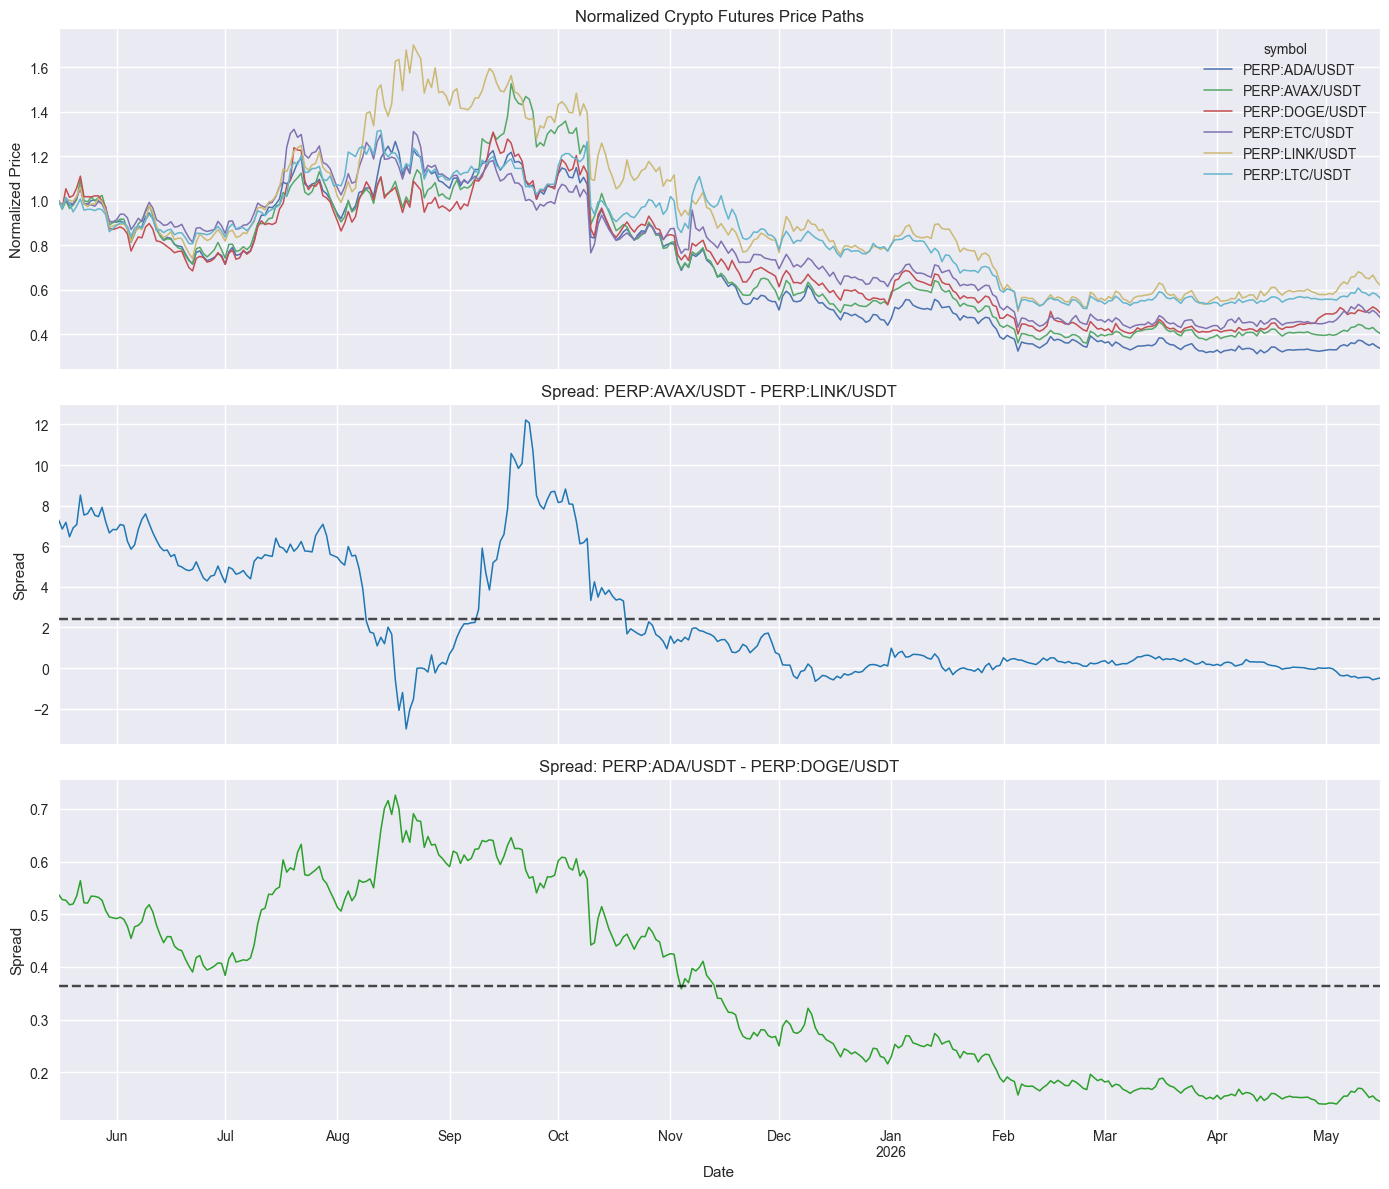

In [3]:
primary_pairs = [
    ("PERP:AVAX/USDT", "PERP:LINK/USDT"),
    ("PERP:ADA/USDT", "PERP:DOGE/USDT"),
]

normalized_close = close_matrix.div(close_matrix.iloc[0])
spread_1 = close_matrix[primary_pairs[0][0]] - close_matrix[primary_pairs[0][1]]
spread_2 = close_matrix[primary_pairs[1][0]] - close_matrix[primary_pairs[1][1]]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

normalized_close.plot(ax=axes[0], lw=1.1)
axes[0].set_title("Normalized Crypto Futures Price Paths")
axes[0].set_ylabel("Normalized Price")

spread_1.plot(ax=axes[1], color="tab:blue", lw=1.1)
axes[1].axhline(spread_1.mean(), color="black", linestyle="--", alpha=0.7)
axes[1].set_title(f"Spread: {primary_pairs[0][0]} - {primary_pairs[0][1]}")
axes[1].set_ylabel("Spread")

spread_2.plot(ax=axes[2], color="tab:green", lw=1.1)
axes[2].axhline(spread_2.mean(), color="black", linestyle="--", alpha=0.7)
axes[2].set_title(f"Spread: {primary_pairs[1][0]} - {primary_pairs[1][1]}")
axes[2].set_ylabel("Spread")
axes[2].set_xlabel("Date")

plt.tight_layout()

## Inspect pair candidates and cointegration

We still run the repo's pair-discovery utilities on the live futures universe. For the backtest itself we choose a non-overlapping pair set so the notebook remains easier to reason about.

In [4]:
candidate_pairs = preselect_pairs_by_correlation(
    close_matrix,
    min_corr=0.45,
    pairs_per_symbol=4,
    max_pairs=12,
)
cointegrated_pairs = find_cointegrated_pairs(
    close_matrix,
    candidate_pairs=candidate_pairs,
    max_pairs=8,
    pvalue_threshold=0.15,
    min_obs=120,
)

candidate_pairs_df = pd.DataFrame(candidate_pairs, columns=["symbol_a", "symbol_b"])
cointegration_df = pd.DataFrame(
    [
        {
            "symbol_a": candidate.symbol_a,
            "symbol_b": candidate.symbol_b,
            "pvalue": candidate.pvalue,
            "test_stat": candidate.test_stat,
        }
        for candidate in cointegrated_pairs
    ]
)

display(candidate_pairs_df)
display(cointegration_df.sort_values("pvalue"))

,symbol_a,symbol_b
0,PERP:ADA/USDT,PERP:DOGE/USDT
1,PERP:ADA/USDT,PERP:LINK/USDT
2,PERP:ADA/USDT,PERP:AVAX/USDT
3,PERP:DOGE/USDT,PERP:ETC/USDT
4,PERP:AVAX/USDT,PERP:LINK/USDT
5,PERP:DOGE/USDT,PERP:LINK/USDT
6,PERP:ADA/USDT,PERP:ETC/USDT
7,PERP:ETC/USDT,PERP:LINK/USDT
8,PERP:AVAX/USDT,PERP:ETC/USDT
9,PERP:ETC/USDT,PERP:LTC/USDT


,symbol_a,symbol_b,pvalue,test_stat
0,PERP:AVAX/USDT,PERP:LINK/USDT,0.0178,-3.7107
1,PERP:AVAX/USDT,PERP:DOGE/USDT,0.0259,-3.5803
2,PERP:ADA/USDT,PERP:DOGE/USDT,0.0431,-3.3931
3,PERP:ADA/USDT,PERP:AVAX/USDT,0.0443,-3.3830
4,PERP:ETC/USDT,PERP:LTC/USDT,0.0524,-3.3176


## Configure the stat-arb strategy and inspect sparse signals

Candidate backtest pairs: [['PERP:AVAX/USDT', 'PERP:LINK/USDT'], ['PERP:ADA/USDT', 'PERP:DOGE/USDT']]
Dropped by Zipline preflight: ['PERP:DOGE/USDT']
Final backtest pairs: [['PERP:AVAX/USDT', 'PERP:LINK/USDT']]


symbol,row_count,aligned_row_count,calendar_loss_ratio,price_scale,max_scaled_price,max_scaled_volume,price_overflow_rows,volume_overflow_rows,valid_for_zipline,failure_reason
str,i64,i64,f64,f64,f64,f64,i64,i64,bool,str
"""PERP:ADA/USDT""",366,366,0.0,1.0,1.0199,3.4694e9,0,0,true,""""""
"""PERP:AVAX/USDT""",366,366,0.0,1.0,36.16,5.392652e7,0,0,true,""""""
"""PERP:DOGE/USDT""",366,366,0.0,1.0,0.30679,2.8545e10,0,287,false,"""volume_overflow"""
"""PERP:ETC/USDT""",366,366,0.0,1.0,25.939,3.4578e7,0,0,true,""""""
"""PERP:LINK/USDT""",366,366,0.0,1.0,27.863,8.4883e7,0,0,true,""""""
"""PERP:LTC/USDT""",366,366,0.0,1.0,136.03,1.7767e7,0,0,true,""""""


date,symbol,signal,weight
date,str,i32,f64
2025-06-13,"""PERP:AVAX/USDT""",1,0.436837
2025-06-13,"""PERP:LINK/USDT""",-1,0.563163
2025-07-03,"""PERP:AVAX/USDT""",0,0.0
2025-07-03,"""PERP:LINK/USDT""",0,0.0
2025-07-15,"""PERP:AVAX/USDT""",-1,0.436837
…,…,…,…
2025-07-17,"""PERP:LINK/USDT""",0,0.0
2025-07-20,"""PERP:AVAX/USDT""",1,0.436837
2025-07-20,"""PERP:LINK/USDT""",-1,0.563163


Sparse signal rows: 80
Active trading days: 215


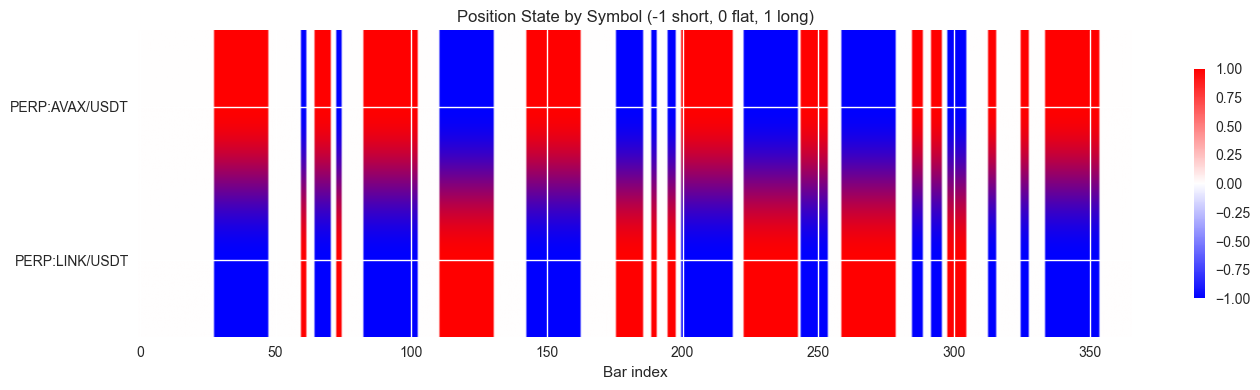

In [5]:
DEFAULT_BACKTEST_PAIRS = [
    ["PERP:AVAX/USDT", "PERP:LINK/USDT"],
    ["PERP:ADA/USDT", "PERP:DOGE/USDT"],
]


def choose_non_overlapping_pairs(discovered_pairs, fallback_pairs, max_pairs: int = 2):
    chosen = []
    used_symbols = set()
    for candidate in discovered_pairs:
        pair = [candidate.symbol_a, candidate.symbol_b]
        if pair[0] in used_symbols or pair[1] in used_symbols:
            continue
        chosen.append(pair)
        used_symbols.update(pair)
        if len(chosen) >= max_pairs:
            return chosen
    for pair in fallback_pairs:
        if pair[0] in used_symbols or pair[1] in used_symbols:
            continue
        chosen.append(pair)
        used_symbols.update(pair)
        if len(chosen) >= max_pairs:
            break
    return chosen



def keep_supported_pairs(pairs, valid_symbols):
    valid_symbol_set = set(valid_symbols)
    return [pair for pair in pairs if pair[0] in valid_symbol_set and pair[1] in valid_symbol_set]


candidate_backtest_pairs = choose_non_overlapping_pairs(cointegrated_pairs, DEFAULT_BACKTEST_PAIRS, max_pairs=2)
config = BacktestConfig(
    workflow="research",
    asset_types=["crypto_futures"],
    universe=UniverseConfig(crypto_futures=sorted(ohlcv["symbol"].unique().to_list())),
    start_date=actual_start,
    end_date=actual_end,
    initial_capital=Decimal("100000"),
    backtest_engine="vectorbt",
    rebalance_frequency="daily",
    commission=CommissionConfig(model="percentage", rate=Decimal("0.0")),
    calendar="crypto",
)

provisional_strategy = StatArbStrategy(
    entry_zscore=1.5,
    exit_zscore=0.5,
    zscore_window=20,
    pairs=candidate_backtest_pairs,
    min_obs=120,
    hedge_method="ols",
    stop_z=3.5,
    max_holding_bars=20,
)

provisional_signals = provisional_strategy.generate_signals(ohlcv)
backtest_ohlcv, _, preflight_report = filter_zipline_compatible_data(
    ohlcv,
    provisional_signals,
    config,
    shift_by_one_bar=True,
    calendar_name=CRYPTO_CALENDAR,
)

valid_symbols = sorted(backtest_ohlcv["symbol"].unique().to_list())
dropped_symbols = sorted(set(ohlcv["symbol"].unique().to_list()) - set(valid_symbols))
backtest_pairs = keep_supported_pairs(candidate_backtest_pairs, valid_symbols)
if not backtest_pairs:
    raise ValueError("Zipline preflight removed every candidate pair. Expand the universe or change the pair set.")

filtered_close_matrix = (
    backtest_ohlcv.select(["date", "symbol", "close"])
    .to_pandas()
    .pivot(index="date", columns="symbol", values="close")
    .sort_index()
)

print("Candidate backtest pairs:", candidate_backtest_pairs)
print("Dropped by Zipline preflight:", dropped_symbols)
print("Final backtest pairs:", backtest_pairs)
display(preflight_report)

strategy = StatArbStrategy(
    entry_zscore=1.5,
    exit_zscore=0.5,
    zscore_window=20,
    pairs=backtest_pairs,
    min_obs=120,
    hedge_method="ols",
    stop_z=3.5,
    max_holding_bars=20,
)

config = BacktestConfig(
    workflow="research",
    asset_types=["crypto_futures"],
    universe=UniverseConfig(crypto_futures=valid_symbols),
    start_date=actual_start,
    end_date=actual_end,
    initial_capital=Decimal("100000"),
    backtest_engine="vectorbt",
    rebalance_frequency="daily",
    commission=CommissionConfig(model="percentage", rate=Decimal("0.0")),
    calendar="crypto",
)

signals = strategy.generate_signals(backtest_ohlcv)
signal_state = (
    signals.to_pandas()
    .pivot(index="date", columns="symbol", values="signal")
    .sort_index()
    .reindex(filtered_close_matrix.index)
    .ffill()
    .fillna(0.0)
)

display(signals.head(12))
print(f"Sparse signal rows: {signals.height}")
print(f"Active trading days: {(signal_state.abs().sum(axis=1) > 0).sum()}")

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(signal_state.T, aspect="auto", cmap="bwr", vmin=-1, vmax=1)
ax.set_yticks(range(len(signal_state.columns)))
ax.set_yticklabels(signal_state.columns)
ax.set_title("Position State by Symbol (-1 short, 0 flat, 1 long)")
ax.set_xlabel("Bar index")
plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()

## Run VectorBT and Zipline on the same live futures dataset

In [6]:
results = {
    "vectorbt": VectorBTProEngine().run(strategy, backtest_ohlcv, config),
}

if ZIPLINE_AVAILABLE:
    results["zipline"] = ZiplineReloadedEngine().run(strategy, backtest_ohlcv, config)
else:
    print("Zipline is not installed. Install `qtradesystematic[zipline]` or `zipline-reloaded` to enable that section.")

list(results)

['vectorbt', 'zipline']

,sharpe,sortino,cagr,max_drawdown,win_rate
engine,,,,,
vectorbt,-0.7338,-0.5778,-0.1447,0.3124,0.3361
zipline,-0.5864,-0.4510,-0.1419,0.3125,0.3224


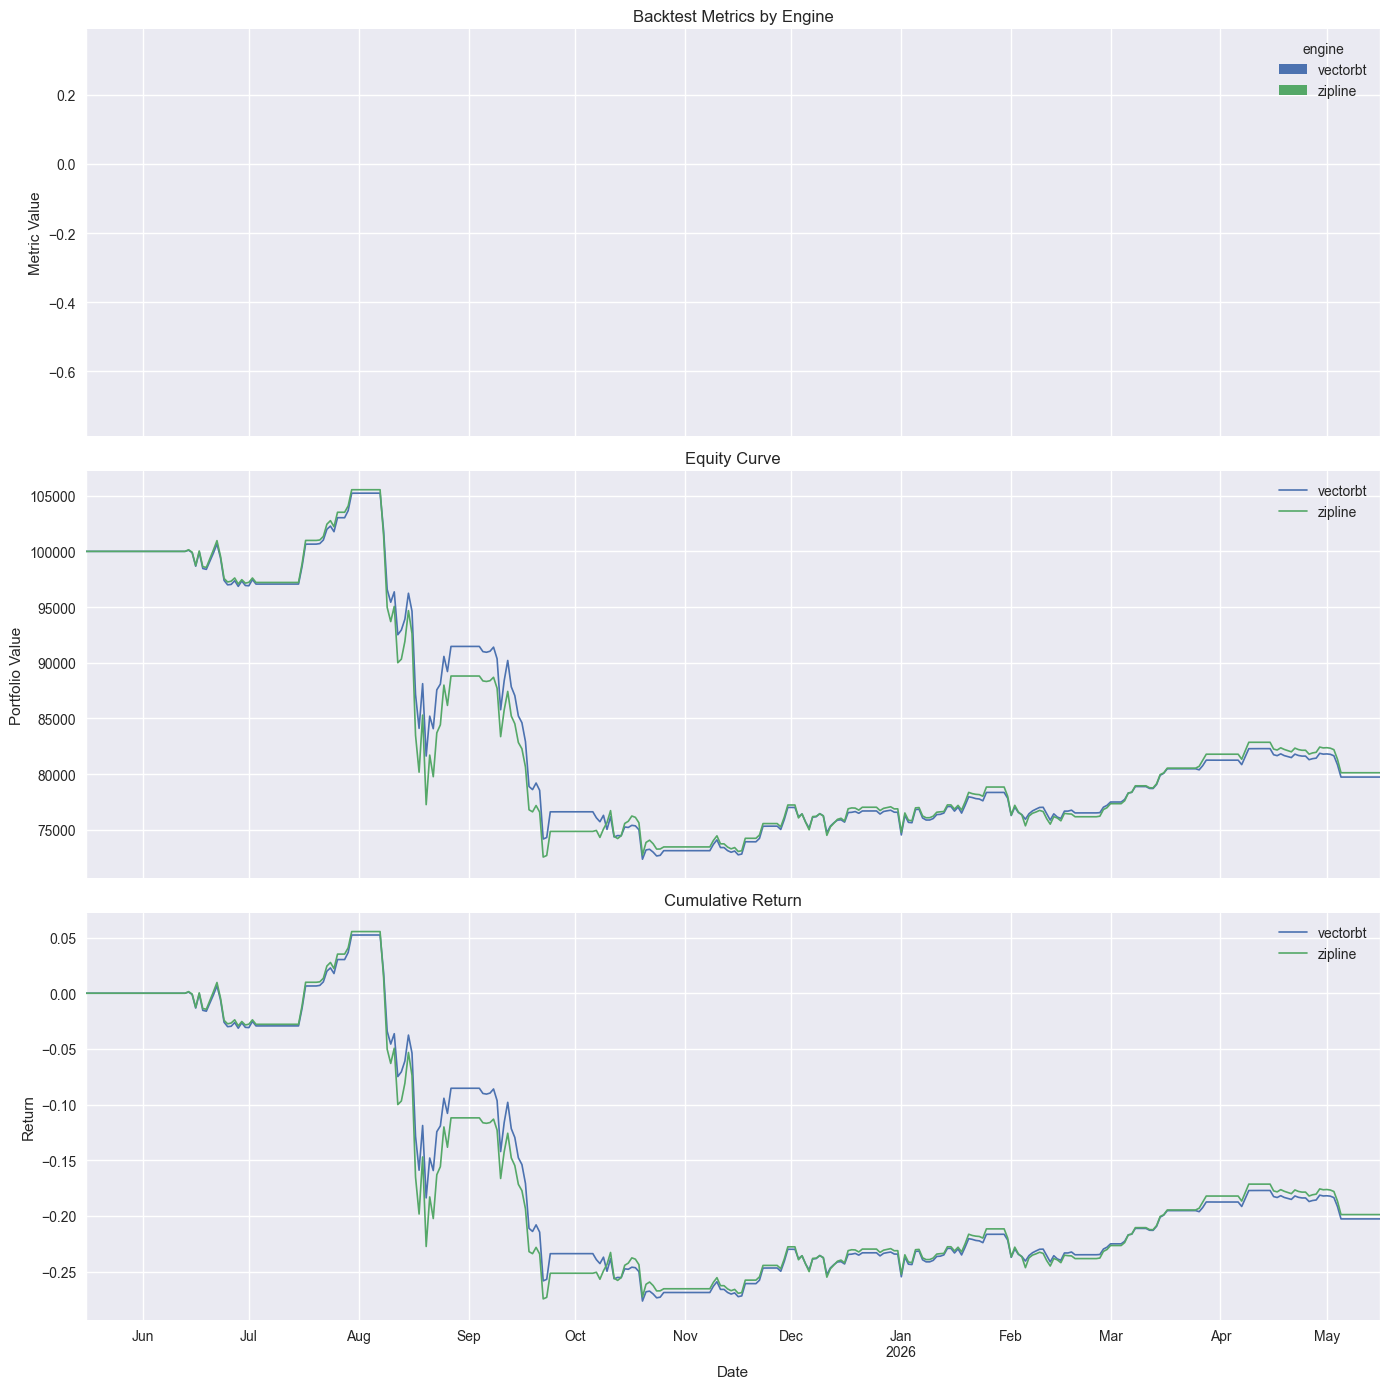

In [7]:
metrics_df = pd.DataFrame({engine_name: result.metrics for engine_name, result in results.items()}).T
metrics_df.index.name = "engine"
display(metrics_df)

returns_df = pd.concat(
    {
        engine_name: result.returns.to_pandas().set_index("date")["portfolio_return"]
        for engine_name, result in results.items()
    },
    axis=1,
).sort_index()
equity_df = pd.concat(
    {
        engine_name: result.equity_curve.to_pandas().set_index("date")["equity"]
        for engine_name, result in results.items()
    },
    axis=1,
).sort_index()
cumulative_return_df = (1.0 + returns_df).cumprod() - 1.0

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

metrics_df.T.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Backtest Metrics by Engine")
axes[0].set_ylabel("Metric Value")
axes[0].tick_params(axis="x", rotation=0)

equity_df.plot(ax=axes[1], lw=1.2)
axes[1].set_title("Equity Curve")
axes[1].set_ylabel("Portfolio Value")

cumulative_return_df.plot(ax=axes[2], lw=1.2)
axes[2].set_title("Cumulative Return")
axes[2].set_ylabel("Return")
axes[2].set_xlabel("Date")

plt.tight_layout()

In [8]:
summary_df = pd.DataFrame(
    {
        "signal_rows": {engine_name: result.signals.height for engine_name, result in results.items()},
        "return_rows": {engine_name: result.returns.height for engine_name, result in results.items()},
        "equity_rows": {engine_name: result.equity_curve.height for engine_name, result in results.items()},
        "start_date": {engine_name: result.returns["date"].min() for engine_name, result in results.items()},
        "end_date": {engine_name: result.returns["date"].max() for engine_name, result in results.items()},
    }
)
display(summary_df)
display(signals.tail(12))

,signal_rows,return_rows,equity_rows,start_date,end_date
vectorbt,80,366,366,2025-05-16,2026-05-16
zipline,80,366,366,2025-05-16,2026-05-16


date,symbol,signal,weight
date,str,i32,f64
2026-03-25,"""PERP:AVAX/USDT""",1,0.436837
2026-03-25,"""PERP:LINK/USDT""",-1,0.563163
2026-03-28,"""PERP:AVAX/USDT""",0,0.0
2026-03-28,"""PERP:LINK/USDT""",0,0.0
2026-04-06,"""PERP:AVAX/USDT""",1,0.436837
…,…,…,…
2026-04-09,"""PERP:LINK/USDT""",0,0.0
2026-04-15,"""PERP:AVAX/USDT""",1,0.436837
2026-04-15,"""PERP:LINK/USDT""",-1,0.563163


## Notes

- This notebook uses real Binance perpetual futures bars, so pair rankings and metrics can change over time.
- The backtest uses `calendar="crypto"` for Zipline even though the symbols are `crypto_futures`, because Binance futures trade continuously and include weekend sessions.
- If you want to expand this into a config-driven workflow next, the same universe can be wired through `qts_flow` using `asset_types: [crypto_futures]` and `data_sources.crypto_futures: binance_futures`.